## Exploratory Data Analysis

### Table of Contents

- [Dependencies](#dependencies--pandas-set-up)
- [Load Data & Set Variables](#load-data--set-variables)
- [Compare Train vs. Real Data](#compare-train-and-real-data)
    - [Missing column 'has_safety_program'](#missing-column-in-real-dataset)
- [Basic Analysis and Fixes](#basic-analysis-and-fixes)
    - [Check Duplicates](#check-duplicates)
    - [Check Data Types](#check-data-types)
        - [Update Date Columns Data Type](#update-date-columns-data-type)
    - [Check Not Available Values](#check-not-available-values)
    - [Check Text and Categorical Data](#check-text-and-categorical-data)
        - [Case Normalization](#case-normalization)
    - [Drop Duplicate Rows](#drop-duplicate-rows)
- [Date Columns Analysis](#date-columns-analysis)
  - [policy_expiration_date & policy_effective_date](#policy_expiration_date--policy_effective_date)
  - [snapshot_date](#snapshot_date)
- [Target Column Analysis](#target-column-analysis)
    - [claim_count](#claim_count)
    - [Target Columns](#target-columns)
- [Check Null Values Details](#check-null-values-details)
    - [driver_avg_age](#driver_avg_age)
    - [driver_count](#driver_count)
    - [prior_year_mileage_000](#prior_year_mileage_000)
    - [prior_loss_amount](#prior_loss_amount)
    - [late_payment_count](#late_payment_count)
    - [payment_frequency](#payment_frequency)
    - [risk_score_external](#risk_score_external)
- [Other Columns Analysis](#other-columns-analysis)
  - [annual_premium](#annual_premium)
  - [vehicle_avg_age](#vehicle_avg_age)
- [Features Selection](#feature-selection)

### Dependencies & pandas set up

In [1]:
import pandas as pd
import numpy as np

from utils import (
    check_duplicates_stats, 
    check_duplicates_per_columns, 
    check_unique_categorical_cols, 
    boxplot_and_histogram,
    countplot,
)

In [2]:
# ---- set display options ----
pd.options.display.max_columns = 40
# pd.options.display.max_rows = 300

[↑ Back to Table of Contents](#table-of-contents)

### Load Data & Set Variables

In [3]:
REAL_DATA = False                   # Defines which csv file should be checked

train = "../data/orig/train.csv"     # ---- train data ----
real = "../data/orig/score.csv"      # ---- real data ----

df_train = pd.read_csv(train)
df_real = pd.read_csv(real)

In [4]:
if REAL_DATA:
    df = df_real                    # ---- load real data ----
    dataset_type = "real data"
else:
    df = df_train                   # ---- load train data ----
    dataset_type = "train data"

print(f"Dataset type - {dataset_type}:", df.shape)


Dataset type - train data: (15075, 31)


[↑ Back to Table of Contents](#table-of-contents)

### Compare Train and Real Data

- Check mismatch in columns (missing columns) between train and real datasets
- target column or columns which are not available at the time when we do predictions can't be used

In [5]:
# ---- Check columns mismatch ----

diff_report = {
    "df_train_only": df_train.columns.difference(df_real.columns).tolist(),
    "df_real_only": df_real.columns.difference(df_train.columns).tolist(),
}

print(diff_report)

{'df_train_only': ['claim_count', 'has_safety_program', 'total_loss_amount'], 'df_real_only': []}


- 'claim_count' --> target column
- 'total_loss_amount' --> column determined by target column
- 'has_safety_program' --> missing column in Real Dataset --> CHECK WHY

[↑ Back to Table of Contents](#table-of-contents)

#### Missing Column in Real Dataset
- 'has_safety_program'

In [6]:
if not REAL_DATA:
    df["target"] = (df["claim_count"] > 0).astype(int)
    df[['has_safety_program',"target"]].value_counts()

In [7]:
# ---- Percentage of 'has_safety_program' cases vs. 'claim_count' ----

if not REAL_DATA:
    ct = pd.crosstab(
        df['has_safety_program'], 
        df['target'], 
        normalize='index', 
        margins=True
    ) * 100

    print(ct.round(2).to_markdown())

| has_safety_program   |     0 |     1 |
|:---------------------|------:|------:|
| 0                    | 85.96 | 14.04 |
| 1                    | 89.71 | 10.29 |
| All                  | 87.66 | 12.34 |


[↑ Back to Table of Contents](#table-of-contents)

### Basic Analysis and Fixes
- Check Duplicates
    - per all columns
    - per primary key 'policy_id'
- Check Data Types
- Check 'Not Available' Values
- Check Mismatch in string values
    - check datetime values
    - fix lower/upper/capital letter inconsistencies
- Drop Duplicates

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15075 entries, 0 to 15074
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         15075 non-null  str    
 1   insured_id                        15075 non-null  str    
 2   snapshot_date                     15075 non-null  str    
 3   policy_effective_date             15075 non-null  str    
 4   policy_expiration_date            15075 non-null  str    
 5   coverage_type                     15075 non-null  str    
 6   vehicle_count                     15075 non-null  int64  
 7   vehicle_avg_age                   15075 non-null  float64
 8   driver_count                      15075 non-null  int64  
 9   driver_avg_age                    14472 non-null  float64
 10  years_in_business                 15075 non-null  float64
 11  prior_year_mileage_000            14172 non-null  float64
 12  business_type  

In [9]:
summary = pd.DataFrame(
    {
        "DataType": df.dtypes,
        "Non-Null Count": df.notnull().sum(),
        "Null Count": df.isnull().sum(),
        "Null %": df.isnull().mean() * 100,  
        "Unique Values": df.nunique(),
        'Example Value': df.iloc[0]
    }
).reset_index(names="Column")

print(summary)

                              Column DataType  Non-Null Count  Null Count  \
0                          policy_id      str           15075           0   
1                         insured_id      str           15075           0   
2                      snapshot_date      str           15075           0   
3              policy_effective_date      str           15075           0   
4             policy_expiration_date      str           15075           0   
5                      coverage_type      str           15075           0   
6                      vehicle_count    int64           15075           0   
7                    vehicle_avg_age  float64           15075           0   
8                       driver_count    int64           15075           0   
9                     driver_avg_age  float64           14472         603   
10                 years_in_business  float64           15075           0   
11            prior_year_mileage_000  float64           14172         903   

In [10]:
if not REAL_DATA:
    all_claims = df.loc[df["claim_count"] > 0, "policy_id"].count()
    all_policies = df["policy_id"].count()
    claims_percentage =  (all_claims / all_policies) * 100

    print(f'claim count > 0: {all_claims}')
    print(f'claim count > 0: {all_claims}')
    print(f'all policies: {all_policies}')
    print(f'percentage: {claims_percentage:.2f}')
    print(f'Nr. of expected claims in Real dataset: {(claims_percentage/100 * df_real["policy_id"].count()):.0f}')

claim count > 0: 1861
claim count > 0: 1861
all policies: 15075
percentage: 12.34
Nr. of expected claims in Real dataset: 370


#### Check Duplicates

There could be:

1. dupliacted values in all columns >> ((Total duplicate rows: 42))
    * maybe incorrect / interupted load and data got loaded twice

2. duplicates per primary key - unique column(s) >> ((Total duplicated rows for policy_id: 150))
    * there must be 1 line per policy_id
    * or combination of policy_id and insured_id & date

In [11]:
check_cols = [
        'policy_id',
        ['policy_id','insured_id'],                   # "policy_id should be enough as it is defined as unique"
        ['policy_id','insured_id','snapshot_date']    # "policy_id should be enough as it is defined as unique"
    ]

In [12]:
check_duplicates_stats(df, check_cols)

for check_col in check_cols:
    check_duplicates_per_columns(df, check_col)

Data contains duplicates: True
Total duplicate rows: 42 

policy_id: True, index: 0
['policy_id', 'insured_id']: True, index: 1
['policy_id', 'insured_id', 'snapshot_date']: True, index: 2


Total duplicated rows for policy_id: 150
Total duplicated rows for ['policy_id', 'insured_id']: 150
Total duplicated rows for ['policy_id', 'insured_id', 'snapshot_date']: 150


Check sample duplicated data
1. rows in dataset which have the same values in all columns

In [13]:
all_duplicates = df[df.duplicated(keep=False)].sort_values(by="policy_id")

all_duplicates.head(6)

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,business_type,state,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,payment_frequency,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report,target
9934,POL-000087,INS-03526,2020-04-16,2019-11-20,2020-11-19,APD,9,5.8,7,48.0,3.8,149.2,Retail,NC,0,0,0.00,250,100,7886.14,Monthly,63.37,1,2,0.0,1,12919.33,2020-05-31,11639.77,Closed,45.0,1
10175,POL-000087,INS-03526,2020-04-16,2019-11-20,2020-11-19,APD,9,5.8,7,48.0,3.8,149.2,Retail,NC,0,0,0.00,250,100,7886.14,Monthly,63.37,1,2,0.0,1,12919.33,2020-05-31,11639.77,Closed,45.0,1
3444,POL-000266,INS-03340,2021-09-28,2021-05-23,2022-05-23,APD,8,9.9,1,53.1,11.3,128.8,Trucking,OH,1,0,1411.34,1000,300,7601.66,Annual,93.21,1,2,1.0,0,0.00,NaN,0.00,No Claim,NaN,0
4207,POL-000266,INS-03340,2021-09-28,2021-05-23,2022-05-23,APD,8,9.9,1,53.1,11.3,128.8,Trucking,OH,1,0,1411.34,1000,300,7601.66,Annual,93.21,1,2,1.0,0,0.00,NaN,0.00,No Claim,NaN,0
127,POL-001140,INS-02828,2021-08-13,2021-06-03,2022-06-03,APD,10,6.0,5,29.0,1.0,386.7,Trucking,CO,3,0,7220.36,250,300,4644.45,Annual,10.57,0,1,0.0,0,0.00,NaN,0.00,No Claim,NaN,0
3740,POL-001140,INS-02828,2021-08-13,2021-06-03,2022-06-03,APD,10,6.0,5,29.0,1.0,386.7,Trucking,CO,3,0,7220.36,250,300,4644.45,Annual,10.57,0,1,0.0,0,0.00,NaN,0.00,No Claim,NaN,0


2. e.g. policy_id == "POL-000567" is duplicated because of inconsistency in "business_type" column 
lower/upper/capitalization inconsistency

In [14]:
df[df["policy_id"] == "POL-000567"]

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,business_type,state,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,payment_frequency,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report,target
52,POL-000567,INS-00888,2020-09-06,2020-07-30,2021-07-30,APD,9,0.0,7,NaN,8.3,366.3,trucking,CO,1,0,15987.66,2500,300,11981.64,Annual,12.65,0,0,0.0,1,4772.75,2020-10-13,2980.24,Open,37.0,1
12881,POL-000567,INS-00888,2020-09-06,2020-07-30,2021-07-30,APD,9,0.0,7,NaN,8.3,366.3,Trucking,CO,1,0,15987.66,2500,300,11981.64,Annual,12.65,0,0,0.0,1,4772.75,2020-10-13,2980.24,Open,37.0,1


In [15]:
df[df["policy_id"] == "POL-000567"][["policy_id", "business_type"]]

,policy_id,business_type
52,POL-000567,trucking
12881,POL-000567,Trucking


[↑ Back to Table of Contents](#table-of-contents)

#### Check Data Types
- are there valid data types pre column per definition (e.g. numeric columns should be numeric)
- aren't there mixed data types per column (e.g. some values are string, some integers)? -> maybe some wrong data within single column?

In [16]:
data_types = {}

for col in df.columns:
    type_counts = df[col].apply(lambda x: type(x).__name__).value_counts()
    data_types[col] = type_counts

data_types_df = pd.DataFrame(data_types).fillna(0).astype(int)

# Transpose so columns = types, rows = features
overview = data_types_df.T
print(overview)


                                  float    int    str
policy_id                             0      0  15075
insured_id                            0      0  15075
snapshot_date                         0      0  15075
policy_effective_date                 0      0  15075
policy_expiration_date                0      0  15075
coverage_type                         0      0  15075
vehicle_count                         0  15075      0
vehicle_avg_age                   15075      0      0
driver_count                          0  15075      0
driver_avg_age                    15075      0      0
years_in_business                 15075      0      0
prior_year_mileage_000            15075      0      0
business_type                         0      0  15075
state                                 0      0  15075
prior_apd_claim_count                 0  15075      0
prior_al_claim_count                  0  15075      0
prior_loss_amount                 15075      0      0
deductible                  

In [17]:
cols = ['float', 'int', 'str']
mask = (overview[cols] > 0).sum(axis=1) >= 2

mixed_features = overview[mask]
print(mixed_features)

                           float  int    str
payment_frequency            452    0  14623
first_claim_reported_date  13214    0   1861


In [18]:
print(df["payment_frequency"].unique())
print(df["first_claim_reported_date"].unique())

<ArrowStringArray>
['Quarterly', 'Annual', 'Monthly', nan]
Length: 4, dtype: str
<ArrowStringArray>
[         nan, '2022-06-15', '2021-07-31', '2020-09-16', '2022-08-02',
 '2021-05-11', '2022-11-23', '2020-12-30', '2020-10-13', '2022-11-27',
 ...
 '2021-09-03', '2021-06-02', '2020-08-11', '2023-02-15', '2020-03-31',
 '2020-10-20', '2020-03-26', '2020-06-23', '2021-05-02', '2021-06-18']
Length: 921, dtype: str


In [19]:
for feat in mixed_features.index:
    float_rows = df[df[feat].apply(lambda x: isinstance(x, float))]
    print(f'{feat}: {float_rows[feat].unique()}')

payment_frequency: <ArrowStringArray>
[nan]
Length: 1, dtype: str
first_claim_reported_date: <ArrowStringArray>
[nan]
Length: 1, dtype: str


##### Update Date Columns Data Type

In [20]:
date_cols = [
    "snapshot_date",
    "policy_effective_date",
    "policy_expiration_date",
    "first_claim_reported_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15075 entries, 0 to 15074
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   policy_id                         15075 non-null  str           
 1   insured_id                        15075 non-null  str           
 2   snapshot_date                     15075 non-null  datetime64[us]
 3   policy_effective_date             15075 non-null  datetime64[us]
 4   policy_expiration_date            15075 non-null  datetime64[us]
 5   coverage_type                     15075 non-null  str           
 6   vehicle_count                     15075 non-null  int64         
 7   vehicle_avg_age                   15075 non-null  float64       
 8   driver_count                      15075 non-null  int64         
 9   driver_avg_age                    14472 non-null  float64       
 10  years_in_business                 15075 non-null  float64

[↑ Back to Table of Contents](#table-of-contents)

#### Check 'Not Available' Values

In [21]:
placeholders = ['?', 'None', 'none', 'N/A', 'n/a', 'NA', 'na', '-999', -999, '']
whitespace_regex = r'^\s*$'

In [22]:
# mask for Null values
null_mask = df.isna()

# mask for Non Available values defined in placeholders list
placeholder_mask = df.isin(placeholders)

summary = pd.DataFrame({
    'nulls': null_mask.sum(),
    'placeholders': placeholder_mask.sum(),
    'total_missing': (null_mask | placeholder_mask).sum()
})

# only not available data
print(summary[summary['total_missing'] > 0])

                            nulls  placeholders  total_missing
driver_avg_age                603             0            603
prior_year_mileage_000        903             0            903
prior_loss_amount            1208             0           1208
payment_frequency             452             0            452
risk_score_external           752             0            752
late_payment_count           1053             0           1053
first_claim_reported_date   13214             0          13214
days_to_first_claim_report  13214             0          13214


In [23]:
null_value_columns = (summary[summary['total_missing'] > 0])
cols_with_nulls = null_value_columns.index.to_list()

df[cols_with_nulls].describe().style.format("{:.2f}")

,driver_avg_age,prior_year_mileage_000,prior_loss_amount,risk_score_external,late_payment_count,first_claim_reported_date,days_to_first_claim_report
count,14472.00,14172.00,13867.00,14323.00,14022.00,1861.00,1861.00
mean,42.11,203.86,9995.51,49.96,0.76,.2f,44.80
min,21.00,6.40,0.00,0.00,0.00,.2f,25.00
25%,36.70,110.60,0.00,24.57,0.00,.2f,40.00
50%,42.10,170.50,3821.17,49.49,0.00,.2f,45.00
75%,47.50,259.82,12825.56,75.28,1.00,.2f,49.00
max,70.00,1639.10,397270.12,100.00,4.00,.2f,70.00
std,8.01,135.29,18338.51,29.06,1.02,nan,6.58


[↑ Back to Table of Contents](#table-of-contents)

#### Check Text and Categorical Data
- inconsistent data - capitals/lower letters -> creating more categories (same meaning, different name)

In [24]:
text_cols = df.select_dtypes(exclude=['number', 'datetime']).columns.tolist()
exclude_ids = ("policy_id", "insured_id")
print(text_cols)

['policy_id', 'insured_id', 'coverage_type', 'business_type', 'state', 'payment_frequency', 'claim_status_current_period']


In [25]:
exclude_target = ("claim_status_current_period", )

categorical_cols = [col for col in text_cols if col not in exclude_ids and col not in exclude_target]
print(categorical_cols)

['coverage_type', 'business_type', 'state', 'payment_frequency']


In [26]:
check_unique_categorical_cols(df, categorical_cols)

ANALYSIS FOR: ---- coverage_type ---- 

<ArrowStringArray>
['APD', 'AL']
Length: 2, dtype: str 

coverage_type
APD    7538
AL     7537
Name: count, dtype: int64 

ANALYSIS FOR: ---- business_type ---- 

<ArrowStringArray>
[     'service',     'Trucking', 'Construction',       'Retail',
        'Other',      'Service', 'construction',        'other',
     'trucking',      'SERVICE',     'TRUCKING',        'OTHER',
       'RETAIL',       'retail', 'CONSTRUCTION',  'Agriculture']
Length: 16, dtype: str 

business_type
Trucking        3367
Retail          2799
Construction    2285
Service         2278
trucking         696
retail           596
Other            573
TRUCKING         473
construction     435
service          431
RETAIL           387
SERVICE          286
CONSTRUCTION     286
other            100
OTHER             75
Agriculture        8
Name: count, dtype: int64 

ANALYSIS FOR: ---- state ---- 

<ArrowStringArray>
['AZ', 'TX', 'NY', 'IL', 'FL', 'OH', 'GA', 'WA', 'NC', 'CO', 'CA

[↑ Back to Table of Contents](#table-of-contents)

##### Case Normalization
- trim data
- lower case data

In [27]:
# ---- Trim and Lower Case Data ----

for col in categorical_cols:
    df[col] = df[col].str.strip().str.lower()

In [28]:
# ---- Check Unique Values ----

for col in categorical_cols:
    print(f'{col}: {df[col].unique()}\n')

coverage_type: <ArrowStringArray>
['apd', 'al']
Length: 2, dtype: str

business_type: <ArrowStringArray>
['service', 'trucking', 'construction', 'retail', 'other', 'agriculture']
Length: 6, dtype: str

state: <ArrowStringArray>
['az', 'tx', 'ny', 'il', 'fl', 'oh', 'ga', 'wa', 'nc', 'co', 'ca', 'pa']
Length: 12, dtype: str

payment_frequency: <ArrowStringArray>
['quarterly', 'annual', 'monthly', nan]
Length: 4, dtype: str



[↑ Back to Table of Contents](#table-of-contents)

#### Drop Duplicate Rows

1. Drop Duplicates for Data in All Columns Duplicated

In [29]:
# ---- Drop duplicates for all columns ----
df.drop_duplicates(inplace=True)

print(f'Cleaned data: {df.shape}')

Cleaned data: (15000, 32)


2. Drop Duplicates Per Selected Columns

In [30]:
# ---- Drop duplicates per column ----
df.drop_duplicates(subset=['policy_id'], inplace=True)

print(f'Cleaned data: {df.shape}')

Cleaned data: (15000, 32)


[↑ Back to Table of Contents](#table-of-contents)

### Date Columns Analysis

- exclude rows where policy_expiration_date < policy_effective_date
- explore snapshot_date vs. policy_effective_date and policy_expiration_date

#### policy_expiration_date & policy_effective_date

In [31]:
# ---- check policy_term_days ----
df["policy_length_days"] = (df["policy_expiration_date"] - df["policy_effective_date"]).dt.days

df["policy_length_days"].value_counts()

policy_length_days
 365    14990
-30        10
Name: count, dtype: int64

In [32]:
# ---- explore suspicious records ----
if REAL_DATA:
    df[df["policy_length_days"] < 0][
        ["policy_id", "policy_effective_date", "policy_expiration_date"]
    ]
else:
    df[df["policy_length_days"] < 0][
        ["policy_id", "policy_effective_date", "policy_expiration_date", "target"]
    ]

In [33]:
# ---- drop 10 records ---- 
df = df[df["policy_length_days"] > 0].copy()
df.shape

(14990, 33)

#### snapshot_date

In [34]:
# ---- snapshot_date <= policy_effective_date | snapshot_date > policy_expiration_date
if not REAL_DATA:
    print(df[(
        (df["snapshot_date"] < df["policy_effective_date"]) |
        (df["snapshot_date"] > df["policy_expiration_date"])
        )][
            ["policy_id","snapshot_date","policy_effective_date","policy_expiration_date","claim_count","target"]
    ].sort_values(by=["policy_id","snapshot_date"]))
else:
    print(df[(
        (df["snapshot_date"] < df["policy_effective_date"]) |
        (df["snapshot_date"] > df["policy_expiration_date"])
        )][
            ["policy_id","snapshot_date","policy_effective_date","policy_expiration_date"]
    ].sort_values(by=["policy_id","snapshot_date"]))

Empty DataFrame
Columns: [policy_id, snapshot_date, policy_effective_date, policy_expiration_date, claim_count, target]
Index: []


In [35]:
#  ---- explore records where snapshot_date == policy_effective_date ----

if not REAL_DATA:
    print(df[(
        (df["snapshot_date"] == df["policy_effective_date"]) &
        (df["target"] == 1)
        )][
            ["policy_id","snapshot_date","policy_effective_date","policy_expiration_date","claim_count","target"]
        ].sort_values(by=["policy_id","snapshot_date"]))

        policy_id snapshot_date policy_effective_date policy_expiration_date  \
7837   POL-000254    2020-12-27            2020-12-27             2021-12-27   
10271  POL-001338    2020-11-20            2020-11-20             2021-11-20   
5197   POL-004715    2020-01-31            2020-01-31             2021-01-30   
5903   POL-006509    2022-01-08            2022-01-08             2023-01-08   
509    POL-006518    2021-09-11            2021-09-11             2022-09-11   
8252   POL-008841    2021-09-26            2021-09-26             2022-09-26   
8185   POL-009245    2022-01-29            2022-01-29             2023-01-29   
4164   POL-009385    2021-11-08            2021-11-08             2022-11-08   
1184   POL-012615    2020-02-14            2020-02-14             2021-02-13   
10517  POL-013284    2022-12-21            2022-12-21             2023-12-21   
11742  POL-013825    2020-12-23            2020-12-23             2021-12-23   

       claim_count  target  
7837      

In [36]:
if not REAL_DATA:
    df["is_day_zero"] = df["snapshot_date"] == df["policy_effective_date"]
    print(df.groupby("is_day_zero")["claim_count"].describe())

               count      mean       std  min  25%  50%  75%  max
is_day_zero                                                      
False        14913.0  0.141890  0.407132  0.0  0.0  0.0  0.0  7.0
True            77.0  0.168831  0.470235  0.0  0.0  0.0  0.0  3.0


In [37]:
# ---- calculate elapsed days ----
df["elapsed_days"] = (df["snapshot_date"] - df["policy_effective_date"]).dt.days

# ---- calculate exposure days with floor ---- 
df["exposure_days"] = df["elapsed_days"].clip(lower=1.0)

# ---- calculate ratio between elapsed_days and policy_length_days----
df["exposure_ratio"] = df["elapsed_days"] / df["policy_length_days"].clip(
    lower=0.0, upper=1.0)

# ---- calculate remaining days ----
df["remaining_days"] = (df["policy_expiration_date"] - df["snapshot_date"]).dt.days

[↑ Back to Table of Contents](#table-of-contents)

### Target Column Analysis
#### claim_count

In [38]:
if not REAL_DATA:
    # Count of claims > 0 
    print(f'claim_count count: {(df["claim_count"] > 0).sum()}\n')

    # Value Count for 'ArithmeticErrorclaim_count'
    df[["claim_count", "target"]].value_counts()

claim_count count: 1853



#### Target Columns

Columns, which may not be available at the time of prediction or may depend on or may determine target column
- "first_claim_reported_date" [_datetime column_]
- "claim_paid_amount_current_period"
- "claim_status_current_period" [_categorical column_]
- "days_to_first_claim_report"
- "total_loss_amount"

In [39]:
target_cols = [
    "claim_count",
    "first_claim_reported_date",                # datetime column
    "claim_paid_amount_current_period",
    "claim_status_current_period",              # categorical column
    "days_to_first_claim_report",
    "total_loss_amount"
]

In [40]:
if not REAL_DATA:
    df[target_cols].info()
else:
    df[target_cols[1:len(target_cols)-1]].info()

<class 'pandas.DataFrame'>
Index: 14990 entries, 0 to 15074
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   claim_count                       14990 non-null  int64         
 1   first_claim_reported_date         1853 non-null   datetime64[us]
 2   claim_paid_amount_current_period  14990 non-null  float64       
 3   claim_status_current_period       14990 non-null  str           
 4   days_to_first_claim_report        1853 non-null   float64       
 5   total_loss_amount                 14990 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(1)
memory usage: 935.7 KB


In [41]:
# ---- categorical columns ----
print(df["claim_status_current_period"].value_counts(), '\n')
print(df["first_claim_reported_date"].value_counts())


claim_status_current_period
No Claim        13137
Open              760
Closed            732
Under Review      361
Name: count, dtype: int64 

first_claim_reported_date
2022-06-27    7
2021-04-04    6
2021-08-09    6
2021-05-25    6
2022-02-07    6
             ..
2020-10-20    1
2020-03-26    1
2020-06-23    1
2021-05-02    1
2021-06-18    1
Name: count, Length: 920, dtype: int64


In [42]:
# ---- numeric columns ----
if not REAL_DATA:
    df[target_cols].describe().style.format({
        "claim_count": "{:.2f}",
        "claim_paid_amount_current_period": "{:.2f}",
        "days_to_first_claim_report": "{:.2f}",
        "total_loss_amount": "{:.2f}",
    })

else:
    df[target_cols[1:len(target_cols)-1]].describe().style.format({
        "claim_paid_amount_current_period": "{:.2f}",
        "days_to_first_claim_report": "{:.2f}",
    })

Check inconsistency of target columns

In [43]:
# ---- Check inconsistency of target columns ----
# Check if there is any inconsistency between 'claim_count' and any other target column
# e.g. 'claim_count' shows 0, but there is "total_loss_amount"

if not REAL_DATA:
    for col in target_cols:
        if col == 'claim_count':
            continue 
        
        print(f'---- {col} ----')
        
        if df[col].dtype == 'float64':
            print(df[(df["claim_count"] == 0) & (df[col] > 0)][target_cols])
            print(f'')
        
        else:
            print(df[(
                (df["claim_count"] == 0) & df[col].notna() & (df[col] != "No Claim") 
                )][target_cols])
            print(f'')

---- first_claim_reported_date ----
Empty DataFrame
Columns: [claim_count, first_claim_reported_date, claim_paid_amount_current_period, claim_status_current_period, days_to_first_claim_report, total_loss_amount]
Index: []

---- claim_paid_amount_current_period ----
Empty DataFrame
Columns: [claim_count, first_claim_reported_date, claim_paid_amount_current_period, claim_status_current_period, days_to_first_claim_report, total_loss_amount]
Index: []

---- claim_status_current_period ----
Empty DataFrame
Columns: [claim_count, first_claim_reported_date, claim_paid_amount_current_period, claim_status_current_period, days_to_first_claim_report, total_loss_amount]
Index: []

---- days_to_first_claim_report ----
Empty DataFrame
Columns: [claim_count, first_claim_reported_date, claim_paid_amount_current_period, claim_status_current_period, days_to_first_claim_report, total_loss_amount]
Index: []

---- total_loss_amount ----
Empty DataFrame
Columns: [claim_count, first_claim_reported_date, clai

[↑ Back to Table of Contents](#table-of-contents)

### Check Null Values Details

In [44]:
null_counts = df.isna().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
print(null_counts)

first_claim_reported_date     13137
days_to_first_claim_report    13137
prior_loss_amount              1198
late_payment_count             1050
prior_year_mileage_000          900
risk_score_external             750
driver_avg_age                  600
payment_frequency               448
dtype: int64


Columns:
- 'first_claim_reported_date'
- 'days_to_first_claim_report'

will be excluded, as they are vailable after claim resolution, not at policy inception

#### driver_avg_age

In [45]:
# ---- driver_avg_age ----
# if driver_count == 0, 'driver_avg_age' should be 0

df[(df["driver_avg_age"].isnull()) & (df["driver_count"] == 0)][["driver_avg_age", "driver_count"]]

,driver_avg_age,driver_count


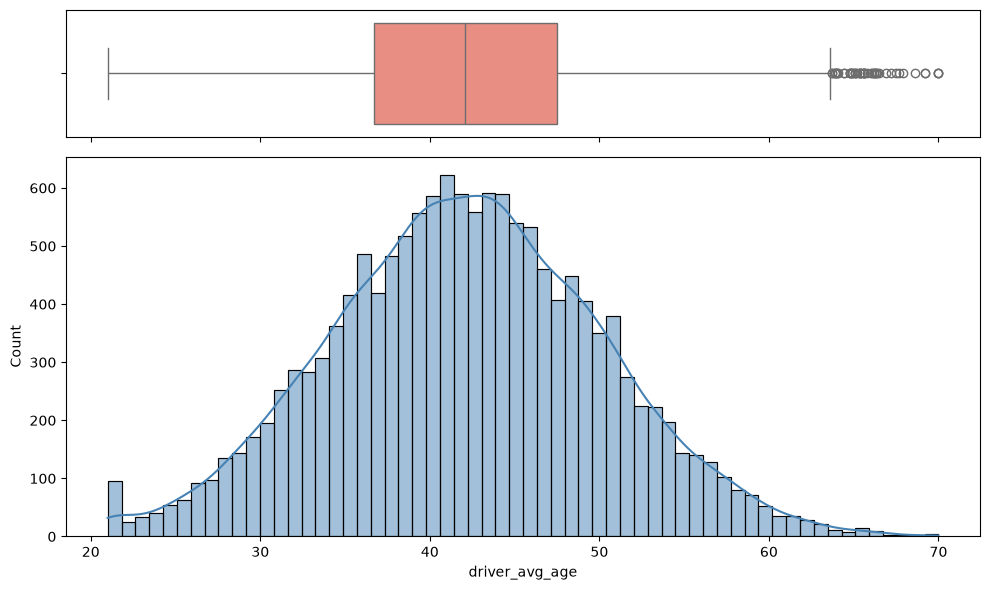

In [46]:
boxplot_and_histogram(df, "driver_avg_age")

#### driver_count
- is related to driver_avg_age

In [47]:
df[(df["driver_count"] == 0) | (df["driver_count"].isna())]

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,business_type,state,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,payment_frequency,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report,target,policy_length_days,is_day_zero,elapsed_days,exposure_days,exposure_ratio,remaining_days


In [48]:
df["driver_count"].unique()

array([ 8,  6,  5,  9,  2,  7,  4,  3, 10, 11,  1, 12, 13, 15, 14, 17, 16,
       18])

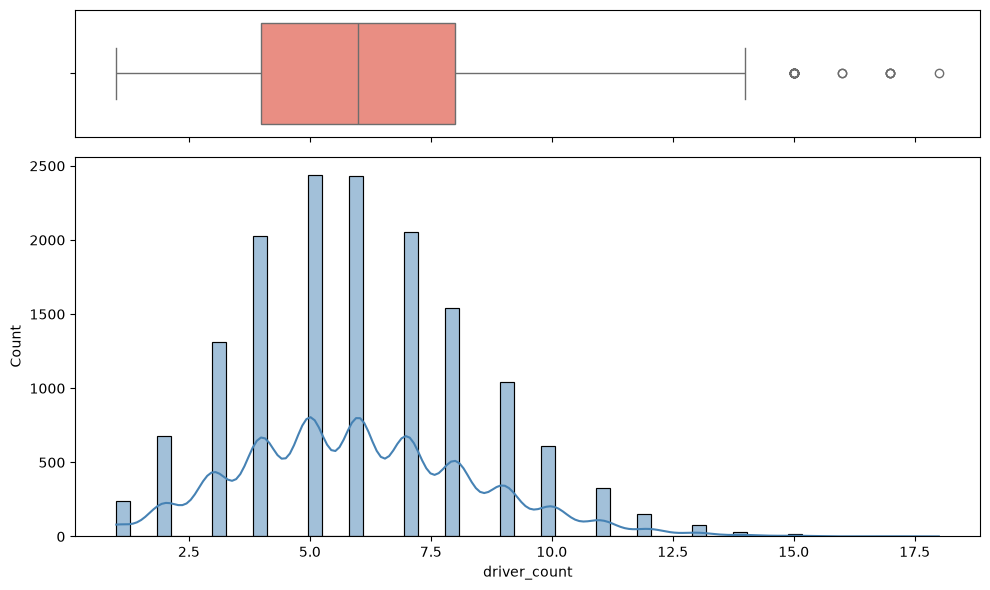

In [49]:
boxplot_and_histogram(df, "driver_count")

#### prior_year_mileage_000
- max amount == 1639.10 looks suspicious (too high) - majority is below 259.82

1. vehicle_count

In [50]:
(
    df[df["prior_year_mileage_000"] > 1000]
    [["prior_year_mileage_000", "vehicle_count","num_heavy_vehicles","driver_count"]]
    .sort_values(by="prior_year_mileage_000", ascending=False)
)

,prior_year_mileage_000,vehicle_count,num_heavy_vehicles,driver_count
5385,1639.1,16,2,3
5346,1436.4,10,0,11
236,1175.4,15,2,9
4707,1172.5,12,2,4
12066,1166.8,12,2,7
9249,1138.3,16,5,3
5764,1128.1,9,4,3
6338,1116.0,8,3,7
5207,1099.4,7,1,1
9168,1085.2,12,4,4


In [51]:
df['total_vehicle_count'] = df['vehicle_count'] + df['num_heavy_vehicles']
df[["vehicle_count","num_heavy_vehicles", "total_vehicle_count"]]

,vehicle_count,num_heavy_vehicles,total_vehicle_count
0,7,0,7
1,6,2,8
2,6,0,6
3,14,3,17
4,7,0,7
...,...,...,...
15070,9,1,10
15071,8,2,10
15072,9,2,11
15073,6,1,7


In [52]:
# ---- mileage_per_vehicle ----
df['mileage_per_vehicle'] = np.where(
    df['total_vehicle_count'] > 0, 
    df['prior_year_mileage_000'] / df['total_vehicle_count'], 
    np.nan
)

In [53]:
df[['prior_year_mileage_000', 'total_vehicle_count', 'mileage_per_vehicle']].describe().style.format("{:.2f}")

,prior_year_mileage_000,total_vehicle_count,mileage_per_vehicle
count,14090.00,14990.00,14088.00
mean,203.88,9.62,21.50
std,135.31,3.60,11.70
min,6.40,0.00,2.11
25%,110.60,7.00,13.27
50%,170.60,9.00,18.94
75%,259.70,12.00,26.71
max,1639.10,30.00,143.64


In [54]:
(
    df[df["prior_year_mileage_000"] > 1000]
    [["prior_year_mileage_000", "mileage_per_vehicle", "total_vehicle_count","driver_count"]]
    .sort_values(by="prior_year_mileage_000", ascending=False)
)

,prior_year_mileage_000,mileage_per_vehicle,total_vehicle_count,driver_count
5385,1639.1,91.061111,18,3
5346,1436.4,143.640000,10,11
236,1175.4,69.141176,17,9
4707,1172.5,83.750000,14,4
12066,1166.8,83.342857,14,7
9249,1138.3,54.204762,21,3
5764,1128.1,86.776923,13,3
6338,1116.0,101.454545,11,7
5207,1099.4,137.425000,8,1
9168,1085.2,67.825000,16,4


In [55]:
if not REAL_DATA:
    df[df['total_vehicle_count'] == 0][
        ['prior_year_mileage_000', 'total_vehicle_count', 'mileage_per_vehicle','driver_count',"target"]
    ]
else:
    df[df['total_vehicle_count'] == 0][
        ['prior_year_mileage_000', 'total_vehicle_count', 'mileage_per_vehicle','driver_count']
    ]


In [56]:
# ---- checking if for those 2 policy_ids any duplicate exists ----
df[(df["policy_id"] == "POL-002779") | (df["policy_id"] == "POL-006375")]

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,business_type,state,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,payment_frequency,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report,target,policy_length_days,is_day_zero,elapsed_days,exposure_days,exposure_ratio,remaining_days,total_vehicle_count,mileage_per_vehicle
9052,POL-002779,INS-03605,2021-03-01,2020-12-30,2021-12-30,apd,0,5.1,9,NaN,3.3,120.2,construction,ca,1,0,7310.92,2500,300,8428.68,monthly,66.79,0,0,0.0,0,0.0,NaT,0.0,No Claim,NaN,0,365,False,61,61,61.0,304,0,NaN
14880,POL-006375,INS-01087,2020-06-08,2020-01-02,2021-01-01,apd,0,1.2,5,39.7,2.0,119.5,trucking,wa,0,0,0.00,250,100,2061.41,monthly,NaN,1,0,1.0,0,0.0,NaT,0.0,No Claim,NaN,0,365,False,158,158,158.0,207,0,NaN


Drop 2 rows with total_vehicle_count == 0

In [57]:
# ---- Check vehicle_count == 0 & num_heavy_vehicles == 0 & prior_year_mileage_000 > 0 ----

invalid_vehicle_mask = ( 
    (df["vehicle_count"] == 0) & (df["num_heavy_vehicles"] == 0)
    ) & (
    (df["prior_year_mileage_000"] > 0) | (df["driver_count"] > 0)
)
display(df[invalid_vehicle_mask])

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,business_type,state,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,payment_frequency,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report,target,policy_length_days,is_day_zero,elapsed_days,exposure_days,exposure_ratio,remaining_days,total_vehicle_count,mileage_per_vehicle
9052,POL-002779,INS-03605,2021-03-01,2020-12-30,2021-12-30,apd,0,5.1,9,NaN,3.3,120.2,construction,ca,1,0,7310.92,2500,300,8428.68,monthly,66.79,0,0,0.0,0,0.0,NaT,0.0,No Claim,NaN,0,365,False,61,61,61.0,304,0,NaN
14880,POL-006375,INS-01087,2020-06-08,2020-01-02,2021-01-01,apd,0,1.2,5,39.7,2.0,119.5,trucking,wa,0,0,0.00,250,100,2061.41,monthly,NaN,1,0,1.0,0,0.0,NaT,0.0,No Claim,NaN,0,365,False,158,158,158.0,207,0,NaN


In [58]:
# ---- Drop 2 rows ----
df = df[~invalid_vehicle_mask].copy()

In [59]:
df.shape

(14988, 40)

In [60]:
df[(df["prior_year_mileage_000"].isnull()) & (df["total_vehicle_count"] == 0)][["prior_year_mileage_000", "total_vehicle_count"]]

,prior_year_mileage_000,total_vehicle_count


In [61]:
df[df["prior_year_mileage_000"] == 0]

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,business_type,state,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,payment_frequency,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report,target,policy_length_days,is_day_zero,elapsed_days,exposure_days,exposure_ratio,remaining_days,total_vehicle_count,mileage_per_vehicle


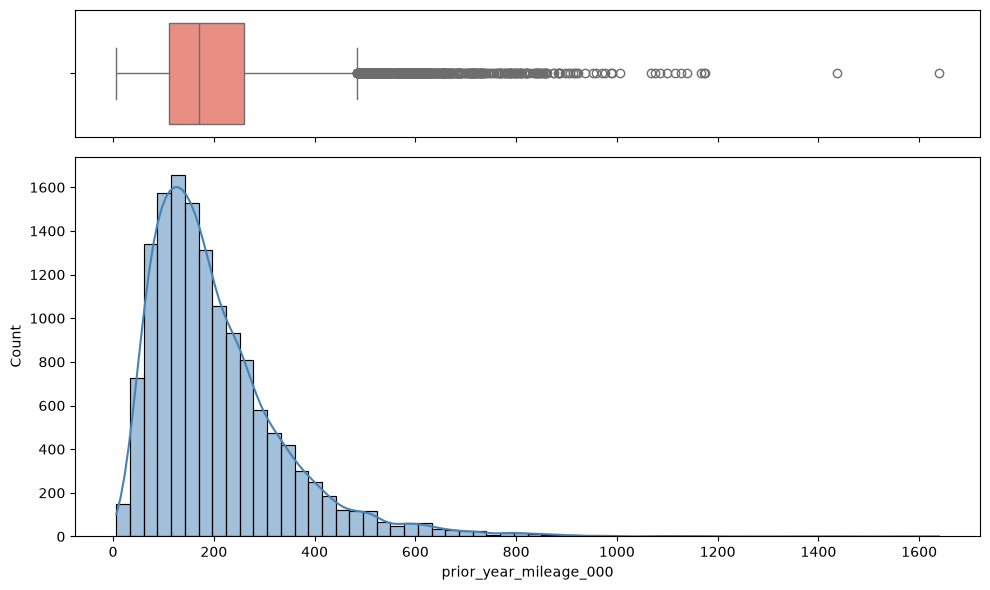

In [62]:
boxplot_and_histogram(df, "prior_year_mileage_000")

In [63]:
# prior_year_mileage_000 may be corelated with 'years_in_business'
df[(df["prior_year_mileage_000"].isnull()) & (df["years_in_business"] == 0)][["prior_year_mileage_000", "years_in_business"]]

,prior_year_mileage_000,years_in_business


In [64]:
df[(df["prior_year_mileage_000"].isnull())][["prior_year_mileage_000", "years_in_business"]].describe()

,prior_year_mileage_000,years_in_business
count,0.0,900.000000
mean,NaN,7.793000
std,NaN,7.742346
min,NaN,1.000000
25%,NaN,2.100000
50%,NaN,5.200000
75%,NaN,10.800000
max,NaN,40.000000


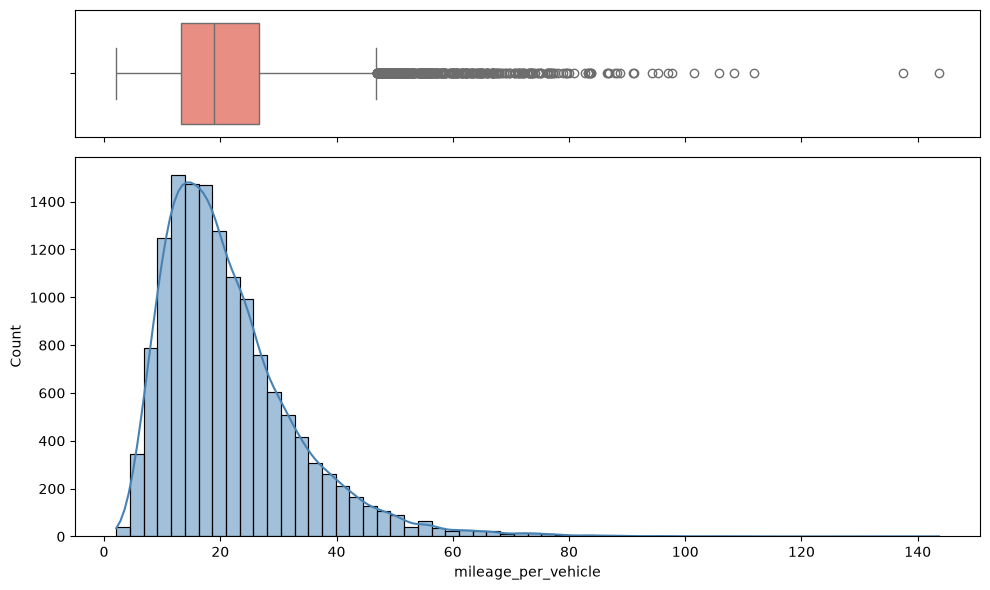

In [65]:
boxplot_and_histogram(df, "mileage_per_vehicle")

#### prior_loss_amount

In [66]:
# ---- prior_loss_amount ----

df[df["prior_loss_amount"].isnull()][["prior_loss_amount","prior_apd_claim_count", "prior_al_claim_count"]]

,prior_loss_amount,prior_apd_claim_count,prior_al_claim_count
3,NaN,0,2
11,NaN,0,0
40,NaN,1,0
80,NaN,1,1
81,NaN,1,1
...,...,...,...
15034,NaN,0,0
15049,NaN,0,0
15056,NaN,2,1
15057,NaN,0,0


In [67]:
df[(
    (df["prior_loss_amount"].isnull()) & (
        (df["prior_apd_claim_count"] > 0 ) | (df["prior_al_claim_count"] > 0 )
    )
    )]

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,business_type,state,prior_apd_claim_count,prior_al_claim_count,prior_loss_amount,deductible,coverage_limit_000,annual_premium,payment_frequency,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report,target,policy_length_days,is_day_zero,elapsed_days,exposure_days,exposure_ratio,remaining_days,total_vehicle_count,mileage_per_vehicle
3,POL-007927,INS-03739,2021-03-12,2020-10-20,2021-10-20,al,14,6.0,9,47.5,18.8,NaN,construction,il,0,2,NaN,500,300,15960.60,annual,43.60,1,3,0.0,0,0.00,NaT,0.00,No Claim,NaN,0,365,False,143,143,143.0,222,17,NaN
40,POL-002232,INS-02189,2020-03-17,2020-02-26,2021-02-25,apd,11,6.4,5,48.7,14.5,483.4,service,nc,1,0,NaN,2500,300,9405.26,monthly,60.63,1,1,1.0,0,0.00,NaT,0.00,No Claim,NaN,0,365,False,20,20,20.0,345,12,40.283333
80,POL-011901,INS-00027,2020-06-18,2020-02-27,2021-02-26,al,7,6.4,8,40.2,1.0,331.7,service,co,1,1,NaN,500,500,12941.26,annual,95.25,0,4,0.0,0,0.00,NaT,0.00,No Claim,NaN,0,365,False,112,112,112.0,253,11,30.154545
81,POL-011443,INS-00175,2022-02-02,2021-10-01,2022-10-01,al,9,9.9,5,47.1,3.2,150.1,trucking,co,1,1,NaN,250,500,8782.06,annual,23.78,0,3,2.0,0,0.00,NaT,0.00,No Claim,NaN,0,365,False,124,124,124.0,241,12,12.508333
122,POL-002141,INS-01223,2022-02-06,2021-12-04,2022-12-04,apd,9,4.4,5,NaN,5.2,173.5,retail,ca,1,0,NaN,5000,100,13640.78,annual,17.02,0,2,0.0,0,0.00,NaT,0.00,No Claim,NaN,0,365,False,64,64,64.0,301,11,15.772727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14935,POL-012707,INS-02272,2021-03-10,2021-01-16,2022-01-16,al,6,4.1,7,31.0,1.9,116.6,retail,az,1,2,NaN,5000,300,7697.53,annual,12.75,0,1,1.0,1,5544.14,2021-05-02,3860.31,Under Review,53.0,1,365,False,53,53,53.0,312,7,16.657143
14949,POL-012077,INS-03650,2022-04-23,2022-03-26,2023-03-26,al,8,3.1,9,41.2,2.9,NaN,trucking,wa,1,0,NaN,1000,500,14149.26,annual,73.63,1,3,3.0,0,0.00,NaT,0.00,No Claim,NaN,0,365,False,28,28,28.0,337,11,NaN
14970,POL-011991,INS-02449,2022-03-22,2022-03-11,2023-03-11,al,10,5.5,6,40.6,20.1,148.8,other,ca,2,1,NaN,2500,300,6826.95,monthly,94.42,0,1,0.0,0,0.00,NaT,0.00,No Claim,NaN,0,365,False,11,11,11.0,354,11,13.527273
15011,POL-010234,INS-00114,2021-07-28,2021-04-14,2022-04-14,al,9,1.3,4,33.3,3.1,292.1,other,ca,0,1,NaN,5000,500,18309.84,annual,2.63,0,4,0.0,0,0.00,NaT,0.00,No Claim,NaN,0,365,False,105,105,105.0,260,13,22.469231


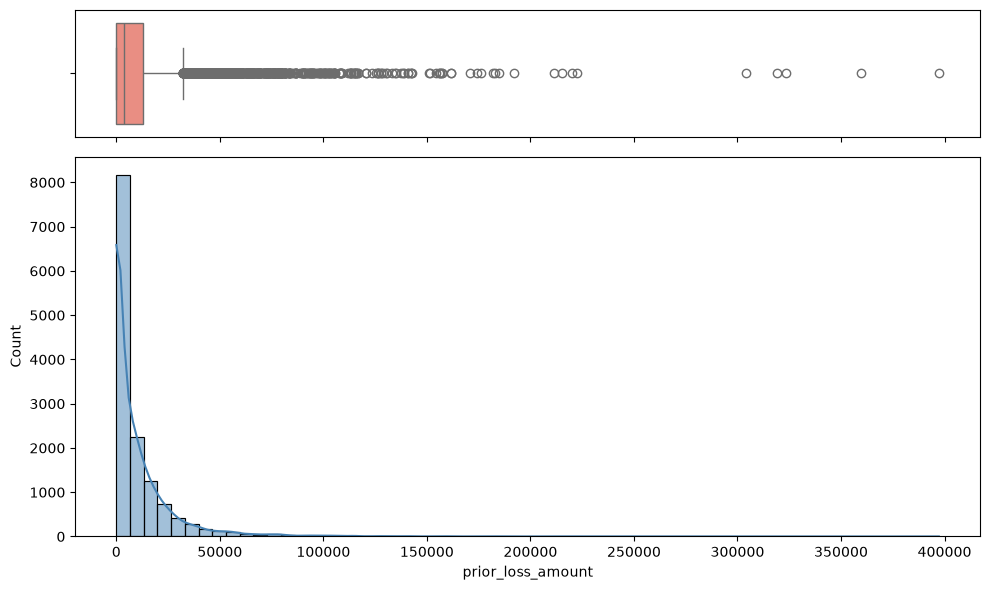

In [68]:
boxplot_and_histogram(df, "prior_loss_amount")

Handle NULL Values for prior_loss_amount

In [69]:
# 1. No Claims
no_claims_mask = (df["prior_apd_claim_count"] == 0) & (df["prior_al_claim_count"] == 0)
df.loc[no_claims_mask & df["prior_loss_amount"].isnull(), "prior_loss_amount"] = 0

# 2. Claims, but missing prior_loss_amount
median_loss = df.loc[df["prior_loss_amount"] > 0, "prior_loss_amount"].median()
df["prior_loss_amount"] = df["prior_loss_amount"].fillna(median_loss)

Create "loss_per_claim"

In [70]:
total_prior_claims = df["prior_apd_claim_count"] + df["prior_al_claim_count"]

df['loss_per_claim'] = np.where(
    total_prior_claims > 0,
    df['prior_loss_amount'] / total_prior_claims, 
    0.0
)

Create 'has_large_prior_loss'

In [71]:
df["has_large_prior_loss"] = (df["prior_loss_amount"] > 50000).astype(int)

#### late_payment_count

In [72]:
df["late_payment_count"].describe()

count    13938.000000
mean         0.755202
std          1.023395
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          4.000000
Name: late_payment_count, dtype: float64

In [73]:
df[df["late_payment_count"].isnull()]["payment_frequency"].value_counts()

payment_frequency
annual       369
monthly      340
quarterly    315
Name: count, dtype: int64

In [74]:
print(pd.crosstab(df["late_payment_count"], df['payment_frequency']))

payment_frequency   annual  monthly  quarterly
late_payment_count                            
0.0                   2655     2572       2236
1.0                   1181     1118        996
2.0                    550      582        465
3.0                    330      308        258
4.0                     98       77         90


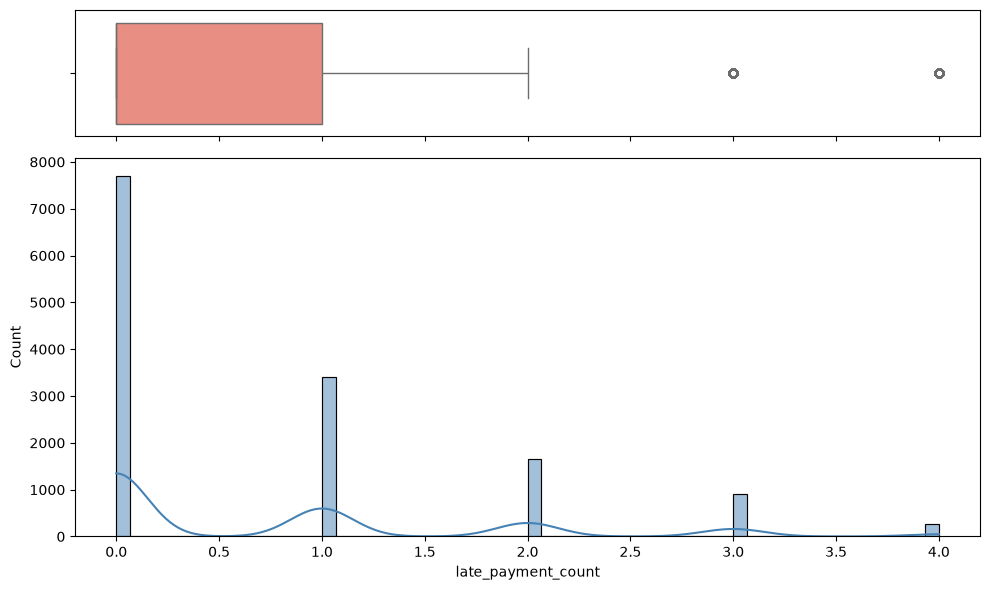

In [75]:
boxplot_and_histogram(df, "late_payment_count")

#### payment_frequency

In [76]:
print(f'Number of Null Values: {df["payment_frequency"].isna().sum()}')
print(f'Number of Unique Values: {df["payment_frequency"].unique()}')

Number of Null Values: 448
Number of Unique Values: <ArrowStringArray>
['quarterly', 'annual', 'monthly', nan]
Length: 4, dtype: str


In [77]:
if not REAL_DATA:
    pd.crosstab(df['payment_frequency'], df['target'])

In [78]:
df[df["payment_frequency"].isnull()]["late_payment_count"].value_counts()

late_payment_count
0.0    234
1.0    116
2.0     48
3.0     19
4.0      5
Name: count, dtype: int64

In [79]:
# ---- check annual payment frequency with late_payment_count > 1 ----
inconsistent_mask = (df["payment_frequency"] == "annual") & (df["late_payment_count"] > 1)
print(f"Number of records (annual & late > 1): {inconsistent_mask.sum()}")

if inconsistent_mask.sum() > 0:
    display(df[inconsistent_mask][["policy_id", "payment_frequency", "late_payment_count", "policy_effective_date", "policy_expiration_date"]])

Number of records (annual & late > 1): 978


,policy_id,payment_frequency,late_payment_count,policy_effective_date,policy_expiration_date
1,POL-003291,annual,3.0,2020-11-26,2021-11-26
25,POL-003861,annual,3.0,2021-03-20,2022-03-20
26,POL-001324,annual,2.0,2022-08-19,2023-08-19
50,POL-010791,annual,3.0,2021-08-03,2022-08-03
81,POL-011443,annual,2.0,2021-10-01,2022-10-01
...,...,...,...,...,...
14993,POL-003944,annual,3.0,2022-11-16,2023-11-16
15041,POL-011097,annual,3.0,2022-06-18,2023-06-18
15051,POL-002434,annual,2.0,2020-10-05,2021-10-05
15061,POL-014424,annual,4.0,2021-01-27,2022-01-27


#### risk_score_external

In [80]:
df['risk_score_external'].describe()

count    14239.000000
mean        49.968432
std         29.054805
min          0.000000
25%         24.630000
50%         49.480000
75%         75.270000
max        100.000000
Name: risk_score_external, dtype: float64

In [81]:
print(f'Number of Null Values: {df['risk_score_external'].isna().sum()}')
print(f'% of Null Values: {(df["risk_score_external"].isnull().mean() * 100):.2f}')
print(f"Number of unique values: {df['risk_score_external'].nunique()}")

Number of Null Values: 749
% of Null Values: 5.00
Number of unique values: 7613


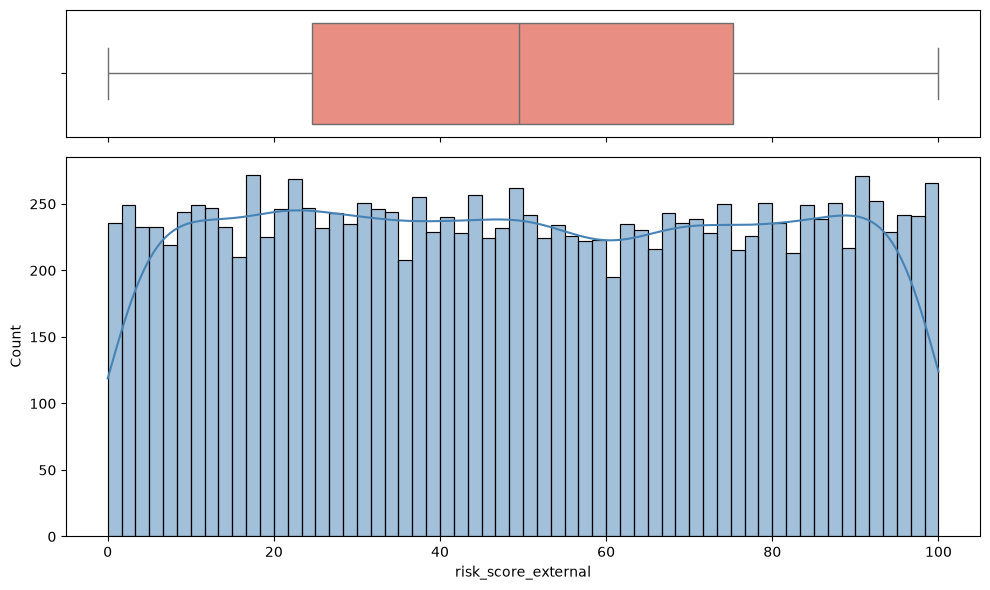

In [82]:
boxplot_and_histogram(df, "risk_score_external")

In [83]:
df["risk_score_external_isna"] = (
    df["risk_score_external"].isna().astype(int)
)

### Other Columns Analysis

In [84]:
ids = ["policy_id", "insured_id"]

not_in_real = ['has_safety_program']

target_columns = [
    "claim_count",
    "target",
    "first_claim_reported_date",
    "claim_paid_amount_current_period",
    "claim_status_current_period",
    "days_to_first_claim_report",
    "total_loss_amount"
]

date_cols = [
    "snapshot_date",
    "policy_effective_date",
    "policy_expiration_date",
    "first_claim_reported_date"
]

# ------- Use Columns -------

target = ["target"]

categorical_cols = ['coverage_type', 'business_type', 'state', 'payment_frequency']

numeric_cols = [
    'vehicle_count', 'num_heavy_vehicles', 'total_vehicle_count',
    'vehicle_avg_age', 'mileage_per_vehicle',
    'driver_count', 'driver_avg_age',
    'years_in_business',
    'prior_apd_claim_count', 'prior_al_claim_count', 'prior_loss_amount',
    'has_large_prior_loss', 'loss_per_claim',
    'late_payment_count',

    'deductible',
    'coverage_limit_000',
    'annual_premium',
    'risk_score_external', 'risk_score_external_isna',

    'policy_length_days', 'exposure_ratio',
]

Help Functions

In [85]:
# Pure numerical columns (floats and integers)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)

# Text / Categorical columns
cat_cols = df.select_dtypes(include=['object', 'category', 'bool', 'str']).columns.tolist()
print(cat_cols)

['vehicle_count', 'vehicle_avg_age', 'driver_count', 'driver_avg_age', 'years_in_business', 'prior_year_mileage_000', 'prior_apd_claim_count', 'prior_al_claim_count', 'prior_loss_amount', 'deductible', 'coverage_limit_000', 'annual_premium', 'risk_score_external', 'has_safety_program', 'num_heavy_vehicles', 'late_payment_count', 'claim_count', 'total_loss_amount', 'claim_paid_amount_current_period', 'days_to_first_claim_report', 'target', 'policy_length_days', 'elapsed_days', 'exposure_days', 'exposure_ratio', 'remaining_days', 'total_vehicle_count', 'mileage_per_vehicle', 'loss_per_claim', 'has_large_prior_loss', 'risk_score_external_isna']
['policy_id', 'insured_id', 'coverage_type', 'business_type', 'state', 'payment_frequency', 'claim_status_current_period', 'is_day_zero']


In [86]:
exclude_cols = set(ids) | set(not_in_real) | set(target_columns)
num_cols = [col for col in num_cols if col not in exclude_cols]
num_cols

['vehicle_count',
 'vehicle_avg_age',
 'driver_count',
 'driver_avg_age',
 'years_in_business',
 'prior_year_mileage_000',
 'prior_apd_claim_count',
 'prior_al_claim_count',
 'prior_loss_amount',
 'deductible',
 'coverage_limit_000',
 'annual_premium',
 'risk_score_external',
 'num_heavy_vehicles',
 'late_payment_count',
 'policy_length_days',
 'elapsed_days',
 'exposure_days',
 'exposure_ratio',
 'remaining_days',
 'total_vehicle_count',
 'mileage_per_vehicle',
 'loss_per_claim',
 'has_large_prior_loss',
 'risk_score_external_isna']

In [87]:
# Numerical columns with low cardinality
discrete_as_num = [col for col in num_cols if df[col].nunique() < 10]
print(f'discrete_as_num: {discrete_as_num}')

discrete_as_num: ['prior_apd_claim_count', 'prior_al_claim_count', 'deductible', 'coverage_limit_000', 'late_payment_count', 'policy_length_days', 'has_large_prior_loss', 'risk_score_external_isna']


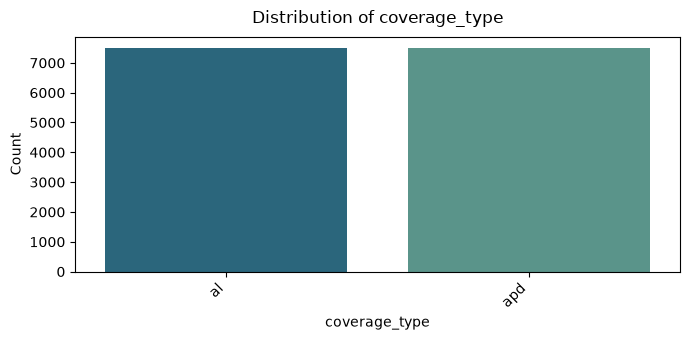

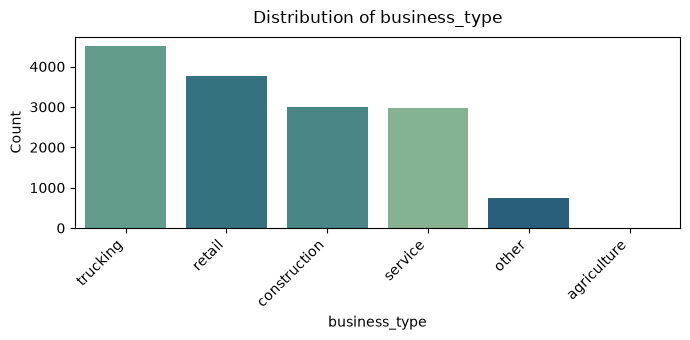

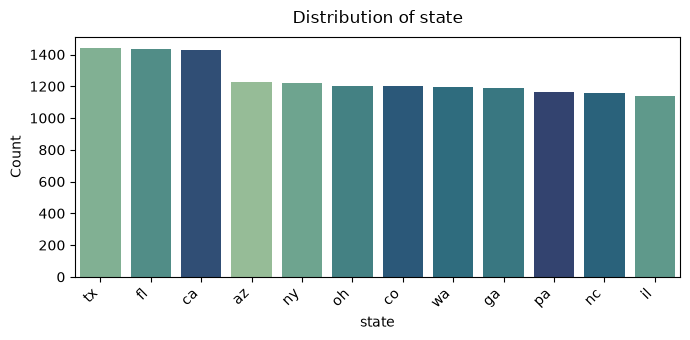

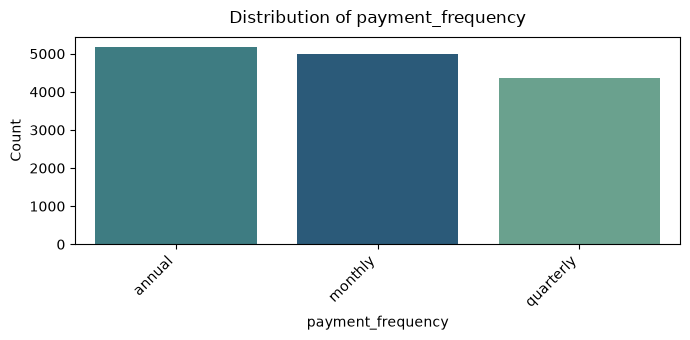

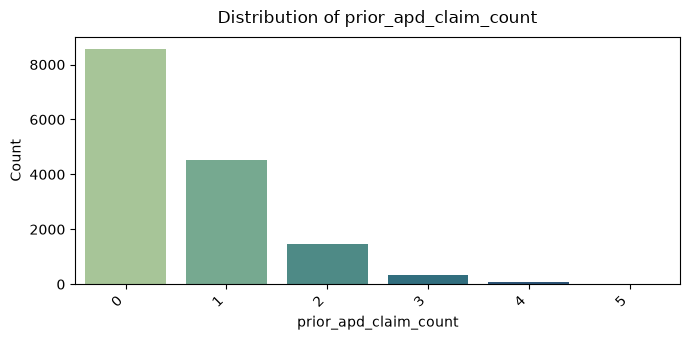

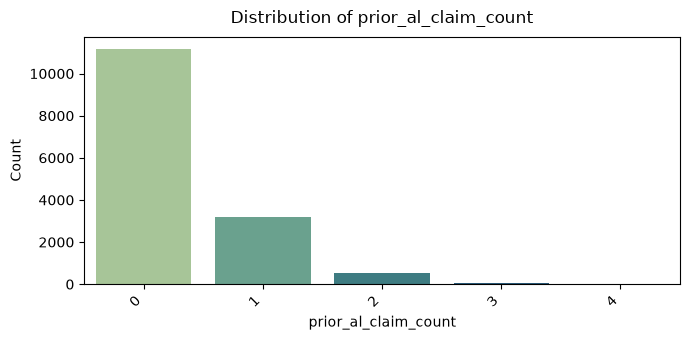

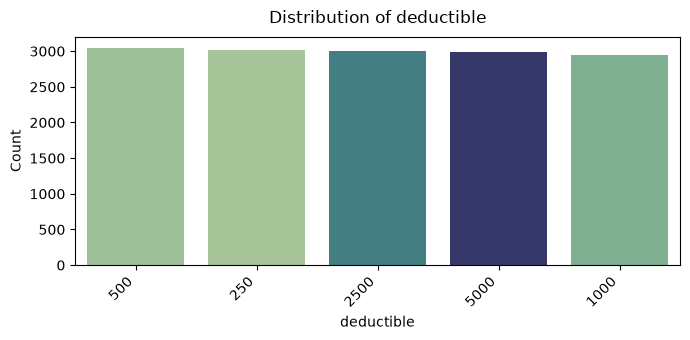

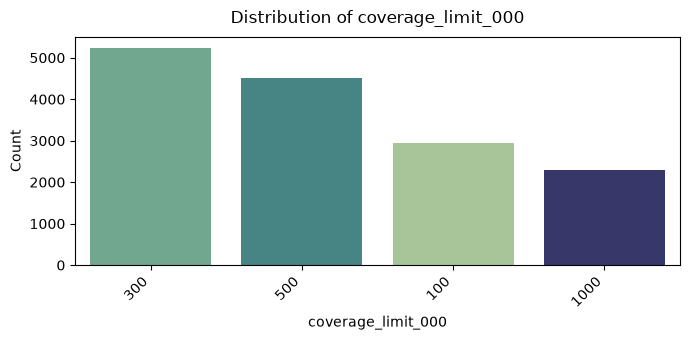

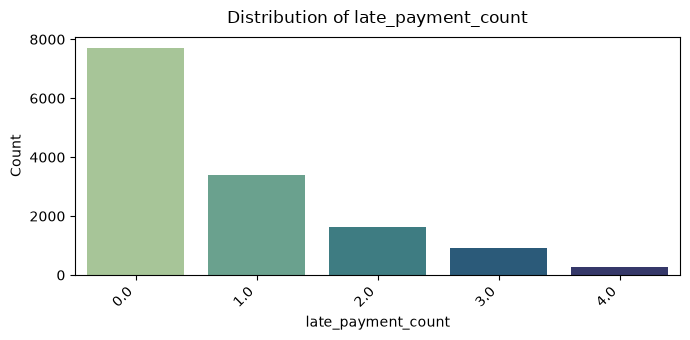

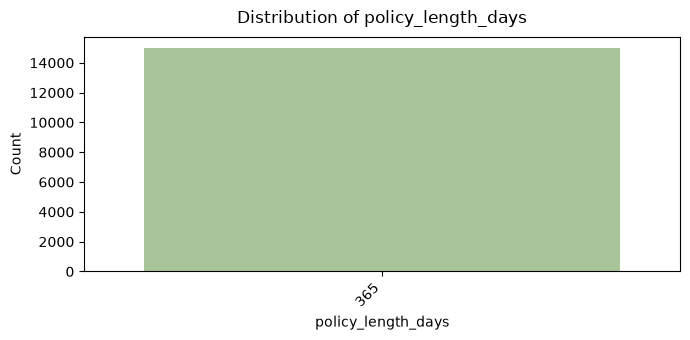

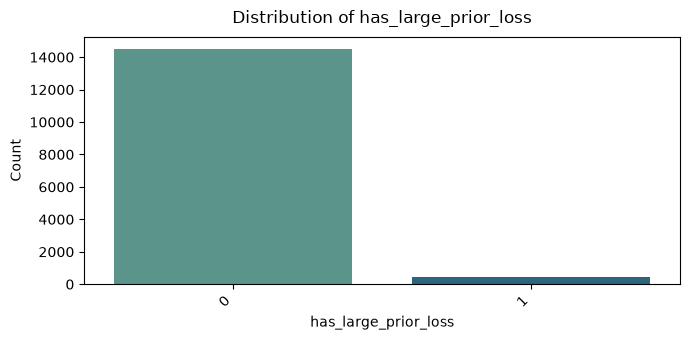

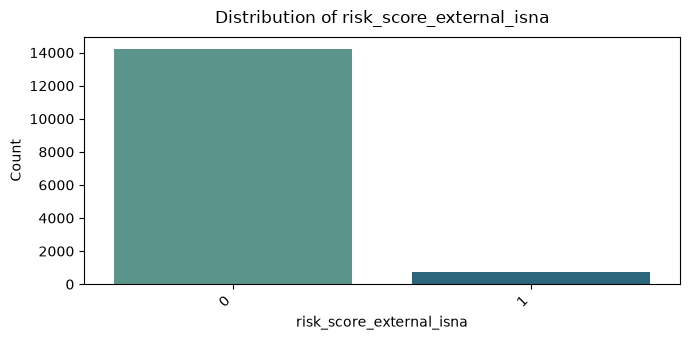

In [88]:
all_categorical_cols = categorical_cols + discrete_as_num

for col in all_categorical_cols:
    countplot(df,col)   

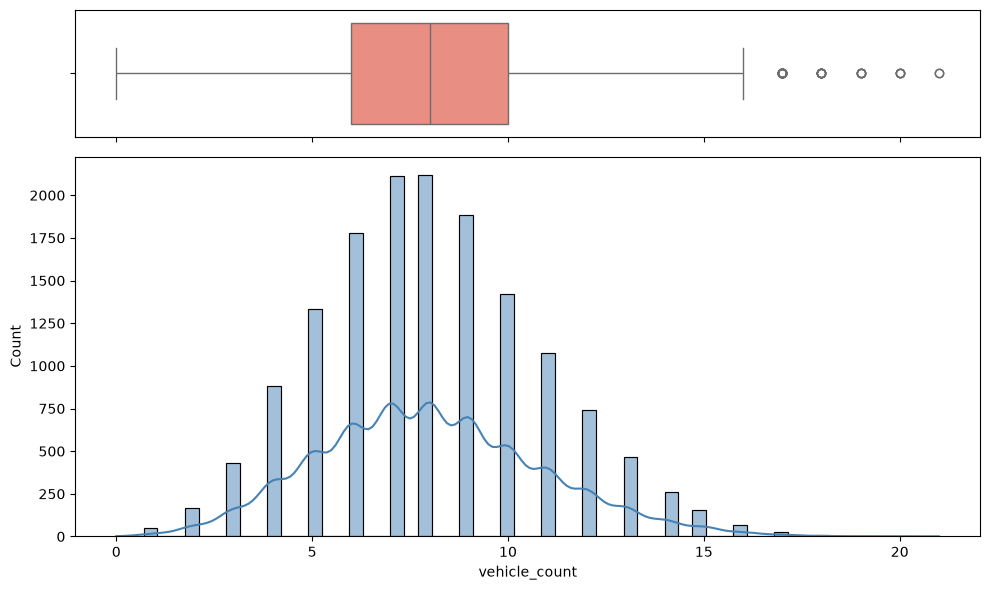

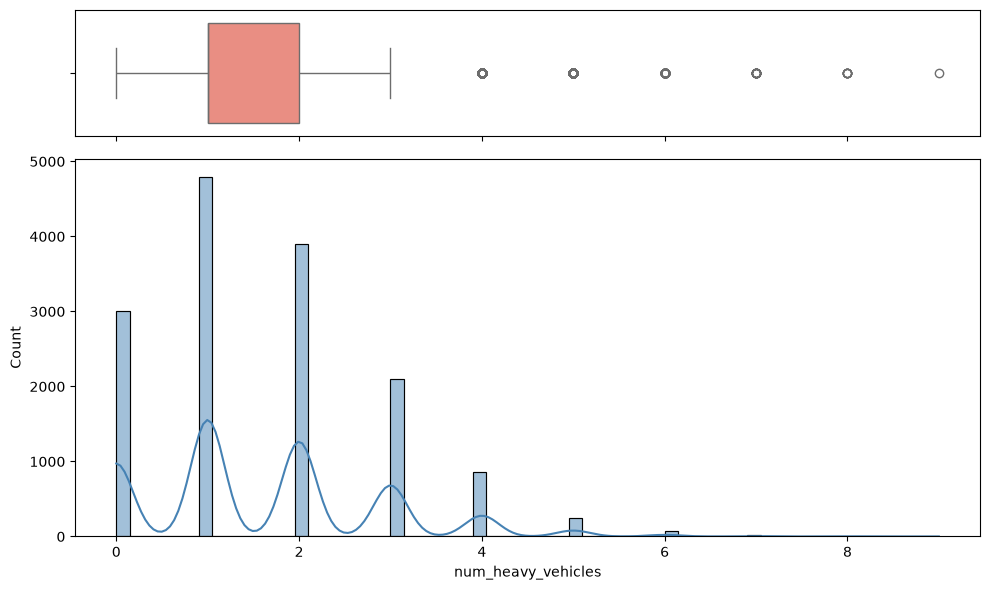

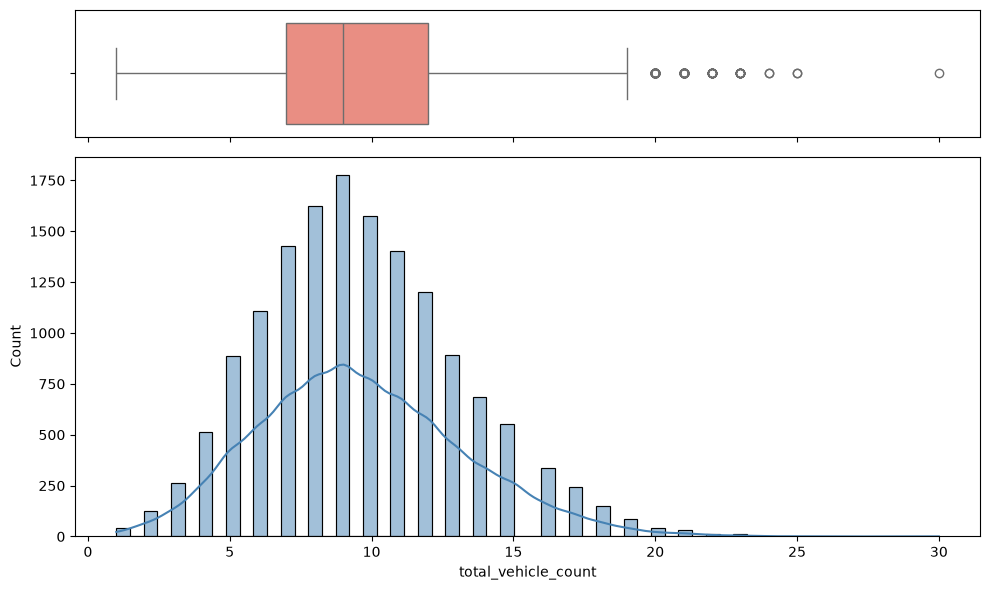

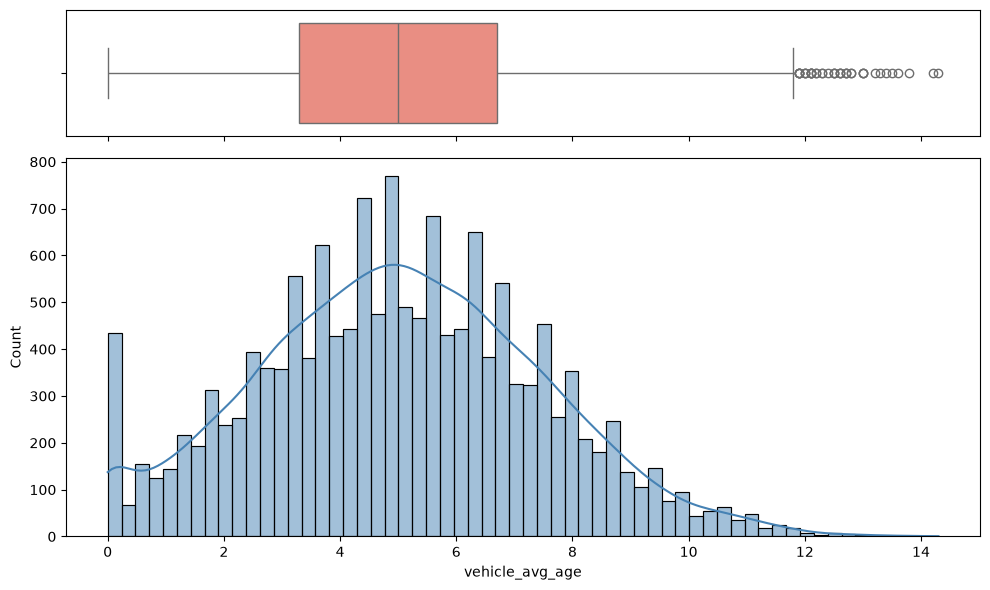

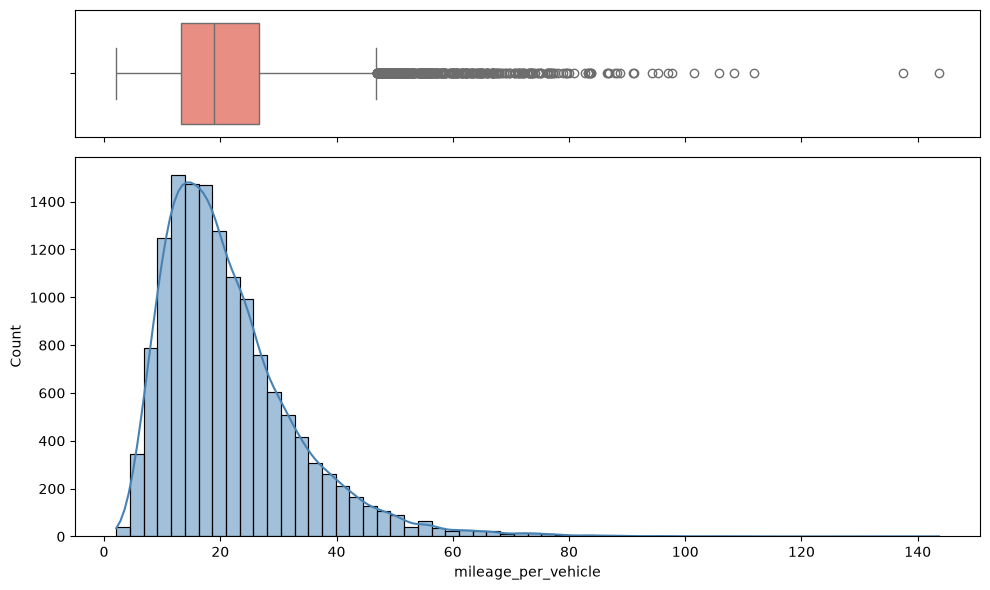

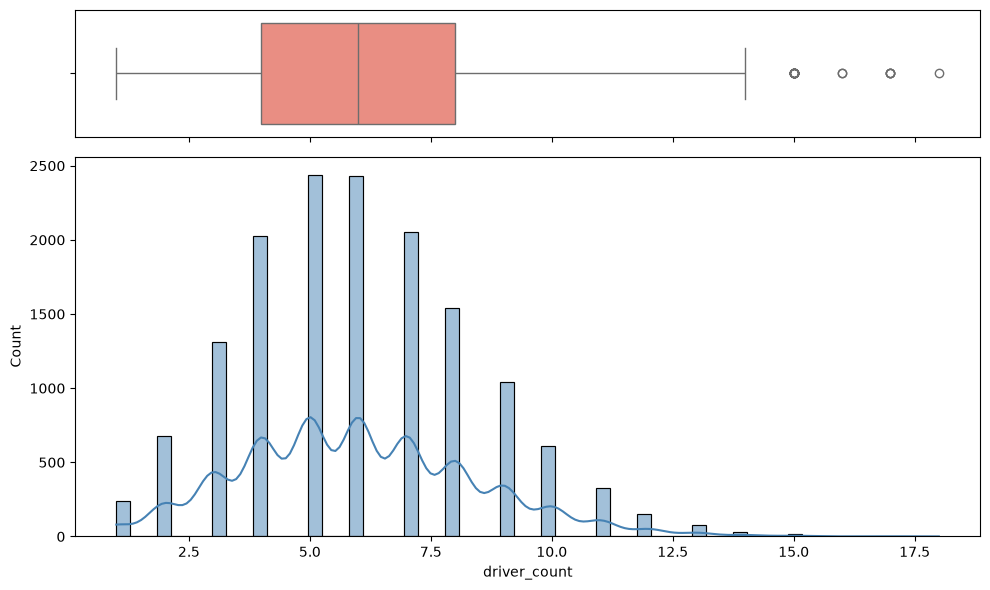

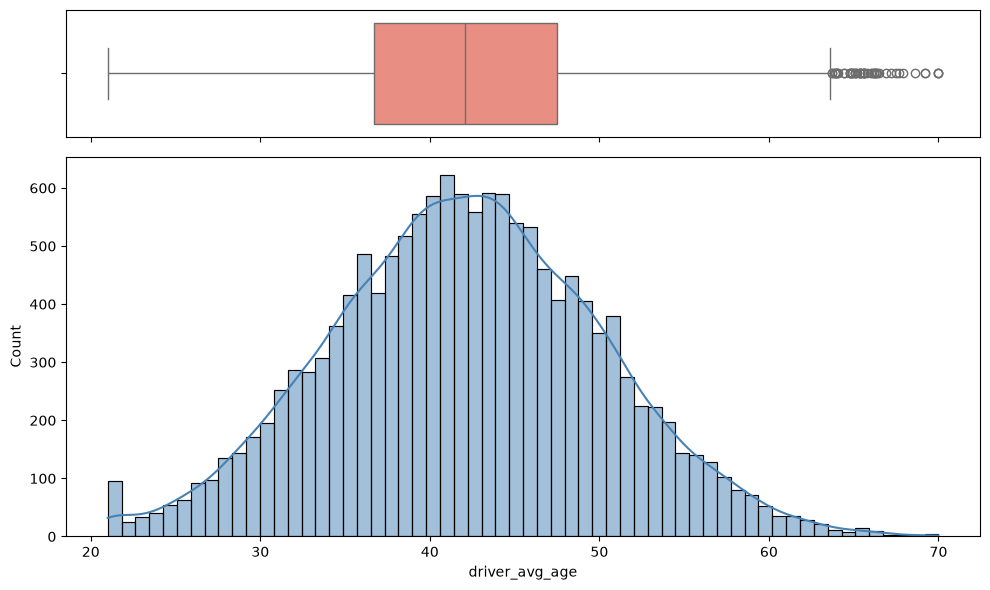

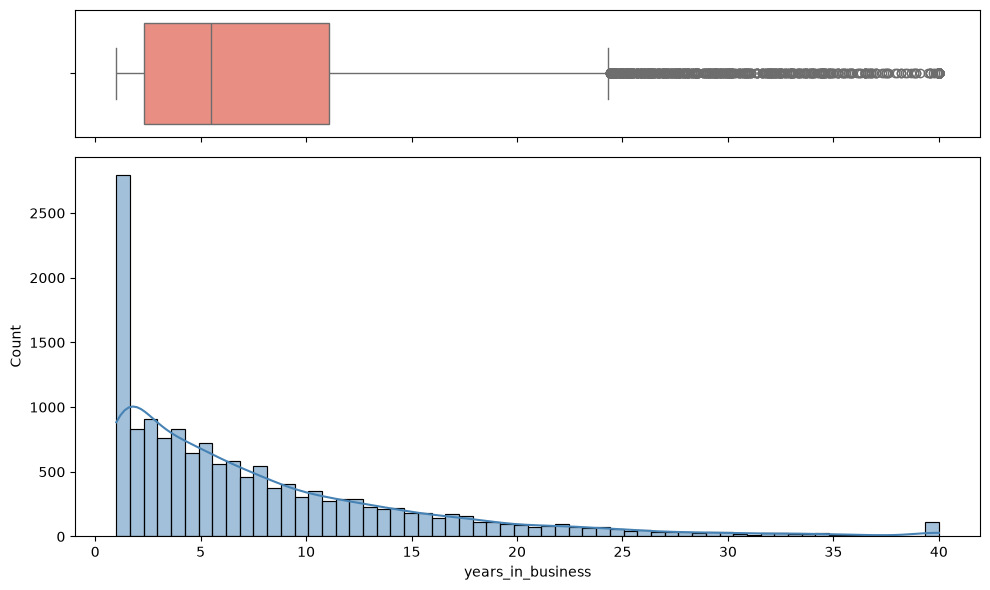

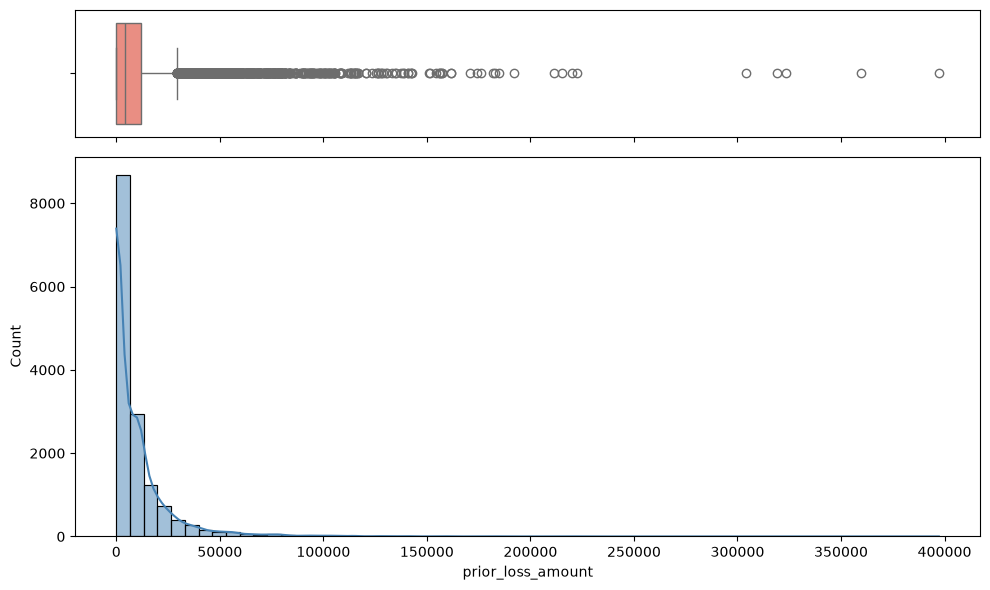

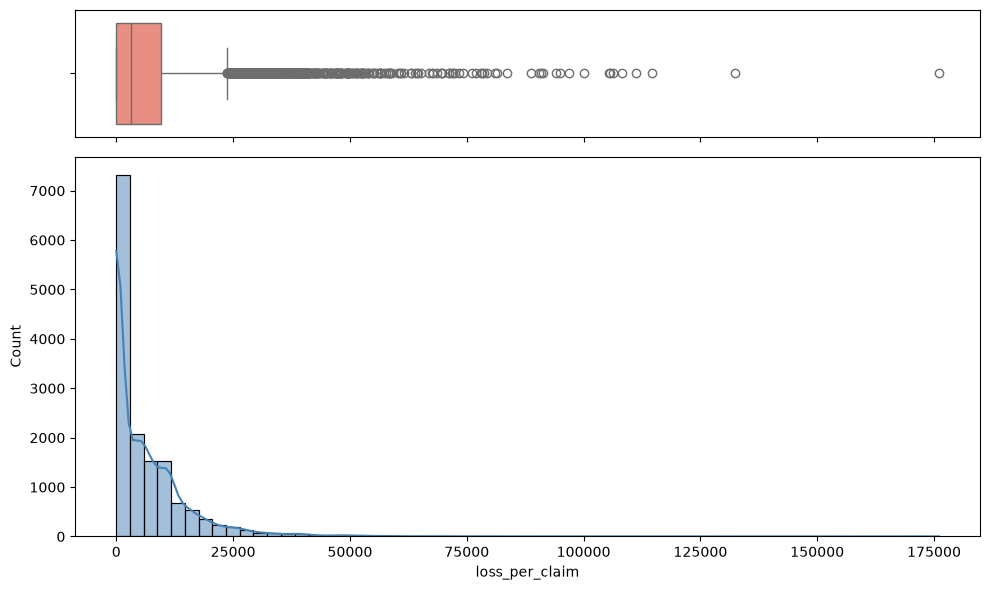

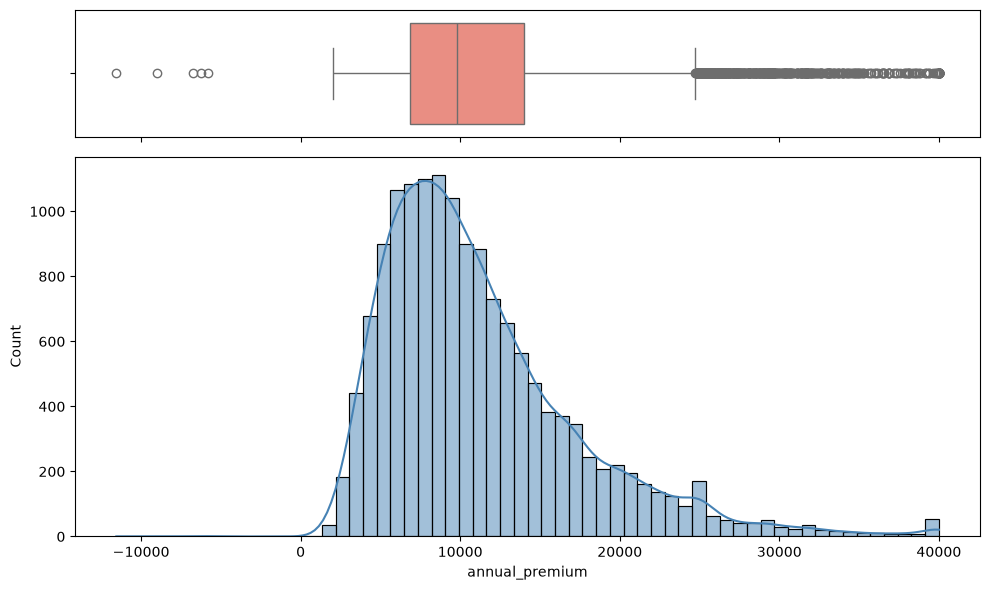

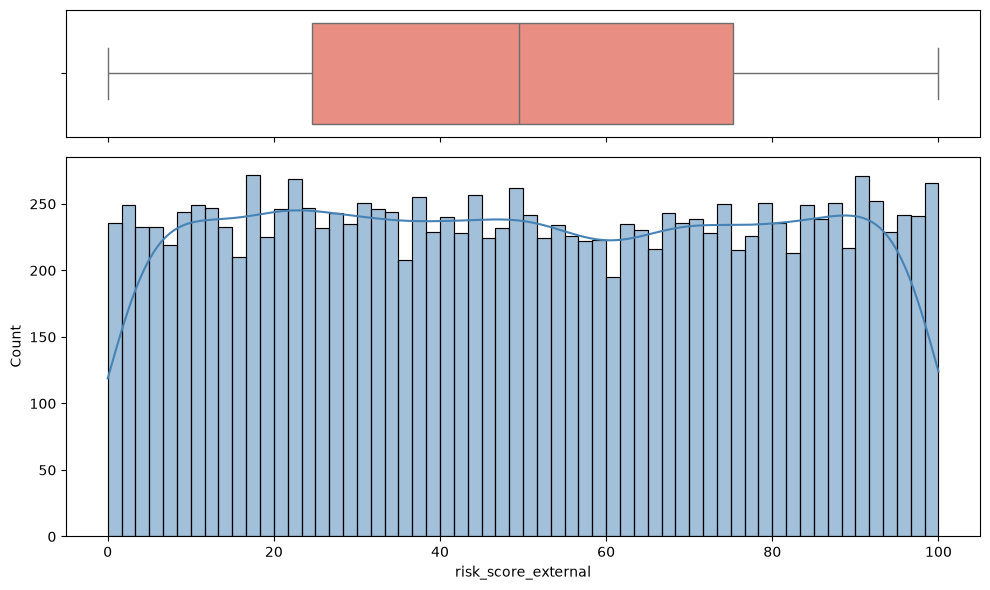

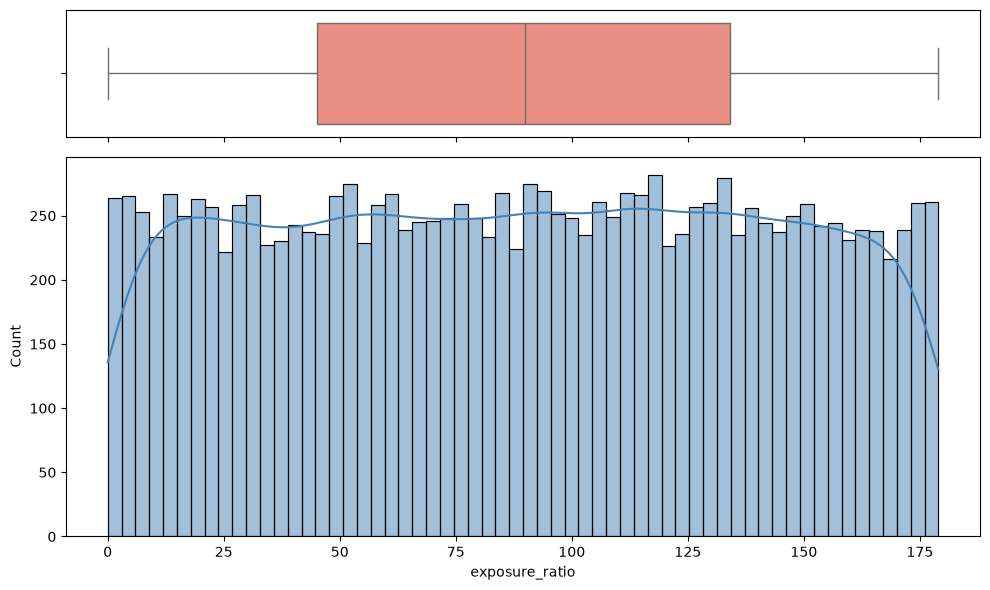

In [89]:
all_numerical_cols = [col for col in numeric_cols if col not in discrete_as_num]

for col in all_numerical_cols:
    boxplot_and_histogram(df, col)

#### annual_premium

In [90]:
df["annual_premium"].describe()

count    14988.000000
mean     11245.851258
std       6206.421130
min     -11553.090000
25%       6851.117500
50%       9792.005000
75%      13999.982500
max      40000.000000
Name: annual_premium, dtype: float64

In [91]:
if not REAL_DATA:
    df[df["annual_premium"] <= 0 ][["policy_id", "annual_premium", "target", "claim_count"]]
else:
    df[df["annual_premium"] <= 0 ][["policy_id", "annual_premium"]]

In [92]:
df = df[df["annual_premium"] >= 0 ].copy()
df.shape

(14983, 43)

#### vehicle_avg_age

In [93]:
df["vehicle_avg_age"].describe()

count    14983.000000
mean         5.022806
std          2.442410
min          0.000000
25%          3.300000
50%          5.000000
75%          6.700000
max         14.300000
Name: vehicle_avg_age, dtype: float64

In [94]:
df_vehicle_avg_age = df[df["vehicle_avg_age"] == 0]

if not REAL_DATA:
    df_vehicle_avg_age[["vehicle_avg_age", "vehicle_count", "num_heavy_vehicles", "total_vehicle_count", "claim_count"]]
else:
    df_vehicle_avg_age[["vehicle_avg_age", "vehicle_count", "num_heavy_vehicles", "total_vehicle_count"]]

In [95]:
pd.crosstab(df_vehicle_avg_age["vehicle_avg_age"], df_vehicle_avg_age["total_vehicle_count"])

total_vehicle_count,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22
vehicle_avg_age,,,,,,,,,,,,,,,,,,,,,
0.0,1,4,13,9,19,19,38,37,39,41,32,29,26,17,9,5,7,5,4,1,2


In [96]:
zero_age = df[df["vehicle_avg_age"] == 0]
print(zero_age["vehicle_count"].describe())

if not REAL_DATA:
    print(f"(Rate: {(zero_age['claim_count'] > 0).mean():.2%})")


count    357.000000
mean       8.072829
std        3.008465
min        1.000000
25%        6.000000
50%        8.000000
75%       10.000000
max       18.000000
Name: vehicle_count, dtype: float64
(Rate: 10.64%)


### Feature Selection

| Column | Keep | Reason | Column Type | Info |
|--------|------|--------|-------------|------|
| `policy_id` | N | Unique policy line identifier | id | N/A |
| `insured_id`| N | ID | id | N/A |
| `snapshot_date` | N | Date column - used for EDA | date | N/A |
| `policy_effective_date` | N | Date column - used for EDA | date | N/A |
| `policy_expiration_date` | N | Date column - used for EDA | date | N/A |
| `coverage_type` | Y | Coverage line: APD (Auto Physical Damage) or AL (Auto Liability) | categorical | OneHotEncoder
| `vehicle_count` | Y | Number of vehicles in the insured's fleet | numeric | median |
| `vehicle_avg_age` | Y | Average age of fleet vehicles in years | numeric | median |
| `driver_count`| Y | Number of drivers listed on the policy | numeric | median but: no nulls, no 0 |
| `driver_avg_age` | Y | Average age of drivers in years | numeric | median - normal distribution |
| `years_in_business` | Y | Number of years the insured company has operated | numeric | median
| `prior_year_mileage_000` | N | Replace with 'mileage_per_vehicle_count' column | numeric | median; RobustScaler |
| `business_type` | Y | Type of business: Trucking, Retail, Construction, Service, Other | categorical | OneHotEncoder
| `state` | Y | US state where the insured is headquartered | categorical | OneHotEncoder
| `prior_apd_claim_count` | Y | Number of APD claims filed in the prior policy period | numeric | median
| `prior_al_claim_count` | Y | Number of AL claims filed in the prior policy period | numeric | median
| `prior_loss_amount` | Y | Total prior period loss amount in USD | numeric | if prior_apd/al_claim_count then prior_loss_amount == 0 -> else median
| `deductible` | Y | Policy deductible in USD (250, 500, 1000, 2500, 5000) | numeric | median
| `coverage_limit_000` | Y | Policy coverage limit in thousands of USD | numeric | median
| `annual_premium` | Y | Annual premium charged in USD | numeric | median
| `payment_frequency` | Y | Premium payment frequency: Monthly, Quarterly, Annual| categorical | "unknown"
| `risk_score_external` | Y | External risk score from 0 (low risk) to 100 (high risk) | numeric | will be handled by XGBoost
| `has_safety_program` | N | Not in real dataset | N/A | N/A |
| `num_heavy_vehicles` | Y | Count of heavy vehicles (trucks, semis) in the fleet | numeric | median
| `late_payment_count` | Y | Number of late premium payments in the current policy year | numeric | median
| `first_claim_reported_date` | N | Determines target - Available after claim resolution, not at policy inception | N/A | N/A |
| `claim_paid_amount_current_period` | N | Determines target - Available after claim resolution, not at policy inception | N/A | N/A |
| `claim_status_current_period` | N | Determines target - Available after claim resolution, not at policy inception | N/A | N/A |
| `days_to_first_claim_report` | N | Determines target - Available after claim resolution, not at policy inception | N/A | N/A |
| `claim_count` | N | Target column | N/A | N/A |
| `total_loss_amount` | N | Determines target | N/A | N/A |
